
#- Support Vector Machines -
---
SVM es un conjunto de algoritmos de aprendizaje supervisado, consiste en encontrar el hiperplano óptimo que mejor separa las clases en un espacio de características. SVM se distingue por buscar aquella que maximiza el margen entre las clases. Este hiperplano de separación constituye la frontera de decisión que divide las clases.

Los elementos clave del algoritmo incluyen los **vectores de soporte**, que son los puntos de datos más cercanos al hiperplano y representan los datos críticos que definen su posición. El **margen**  representa la distancia entre el hiperplano y los vectores de soporte más cercanos de cada clase, y el objetivo principal de SVM es maximizar este margen.




## Exploración de datos

Se procede a utilizar el segundo dataset contenido en el archivo *ejs_svm.pkl*, el cual es procesado mediante la clase SVC del módulo svm.

In [9]:
!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/main/data/ejs_svm.pkl


--2025-10-18 00:42:47--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/main/data/ejs_svm.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15882 (16K) [application/octet-stream]
Saving to: ‘ejs_svm.pkl.1’

ejs_svm.pkl.1       100%[===================>]  15.51K  --.-KB/s    in 0.001s  

2025-10-18 00:42:47 (28.2 MB/s) - ‘ejs_svm.pkl.1’ saved [15882/15882]



In [10]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler

In [11]:
# Cargar datos
with open('ejs_svm.pkl', 'rb') as f:
    data = pickle.load(f)

# Usar segundo dataset
X = data['2do Dataset']['X']
y = data['2do Dataset']['y'].flatten()


## Clasificación SVM con Kernel gaussiano (RBF)

Para la implementación del clasificador SVM se utilizo un kernel gaussiano, el cual permite transformar el espacio de caracteristicas original a un espacio de mayor dimensión donde los datos pueden ser linealmente separables. Este kernel se basa en:

$$ k(x_1,x_2) = e^{-γ||x_1-x_2 ||^2}$$

donde $γ$ es un hiperparametro que controla el alcance de influencia de cada ejemplo de entrenamiento.

El primer modelo es configurado con un valor de $γ = 50$, lo cual representa un valor bastante alto que hace que cada punto de entrenamiento tenga una zona de influencia reducida, resultando en una frontera más compleja y acotada a los datos. Luego, el parametro de regularización C se establecio en 1, este parametro controla el balance entre maximizar el margen de separación y minimizar los errores de clasificación. Este valor hace que el modelo sea capaz de tolerar ciertos errores para evitar un sobre-ajuste excesivo.


In [12]:
svm = SVC(kernel='rbf', gamma=50, C=1)
svm.fit(X, y)

SVC(C=1, gamma=50)

### Visualización de la frontera de decisión y vectores soporte

Para visualizar el comportamiento del clasificador SVM, se desarrollo la función *frontera_decision*, dado que luego en items posteriores se va a tener que realizar diferentes gráficos. Esta función recibe como parámetros los datos de entrada $X$, las etiquetas $y$, el modelo entrenado y un titulo para el gráfico. Se eligio una resolución de 0.005, este parametro determina el tamaño del paso entre puntos consecutivos, mientras mas chico la calidad visual mejora a costa de una complejidad computacional.

La imagen generada muestra como el clasificador SVM establece una frontera de decisión no lineal que separa las dos clases, evidenciando que los vectores de soporte son efectivamente los puntos más cercanos a esta frontera y los que determinan su posición y forma.

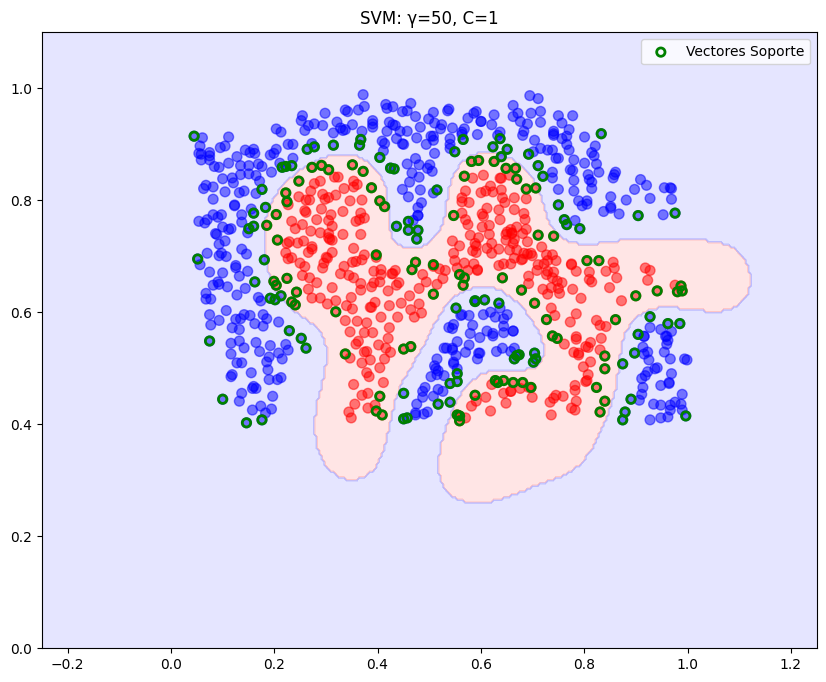

In [20]:
def frontera_decision(X, y, modelo, titulo):
    h = 0.005
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

      # dos colores para clases 0 y 1
    cmap_light = ListedColormap(["#FFAAAA", "#AAAAFF"])
    cmap_bold = ListedColormap(["#FF0000", "#0000FF"])

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z,alpha=0.3, cmap=cmap_light)

    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap= cmap_bold,
               s=50,marker='o', alpha = 0.5)

    plt.scatter(modelo.support_vectors_[:, 0],
                modelo.support_vectors_[:, 1],
             linewidth=2, facecolors='none',
                edgecolors='green', label='Vectores Soporte')
    plt.xlim(-0.25,1.25)
    plt.ylim(0,1.1)
    plt.title(titulo)
    plt.legend()
    plt.show()

frontera_decision(X, y, svm, 'SVM: γ=50, C=1')

### Diferentes valores de C

Se repite el mismo procedimiento pero para diferentes valores del parámetro de regularización C. Este parametro controla el equilibrio entre tener un margen de separación amplio y clasificar correctamente los puntos de entrenamiento.

*  Para el caso de C = 0.1 y $γ = 50$, en este caso tenemos un C bajo, esto indica que el modelo prioriza un margen de separación más amplio, incluso si esto significa aceptar más errores de clasificación en los datos de entrenamiento. Con el alto valor de γ esto le da al modelo una alta sensibilidad a la proximidad de los puntos, esto combinado con un C bajo, esto resulta en una frontera de decisión que no se ajusta perfectamente a los datos.

* Para el caso de C = 10 y $γ = 50$ se puede ver que la frontera de decisión se complejizo y se adapto a cada detalle de los datos de entrenamiento. Este valor de C más elevado indica una penalización alta por errores de clasificación, lo que fuerza al modelo a encontrar una frontera que clasifique mucho mejor cada punto de entrenamiento. Como vemos también el número de vectores de soporte disminuye, dado que un C mas elevado conlleva un margen más estrecho y a que menos puntos se consideren ''errores''.

* Por último para el caso de C = 100, este es un valor muy elevado por lo que el modelo impone una penalización severa a cualquier error de penalización en el conjunto de entrenamiento. El número de vectores de soporte es muy bajo y esto tiene sentido teniendo en cuenta lo explicado en el anterior caso. Como vemos en el gráfico la frontera de decisión se ajusta perfectamente a los datos de entrenamiento, esta capacidad de ajuste casi perfecta es una señal de overfitting.

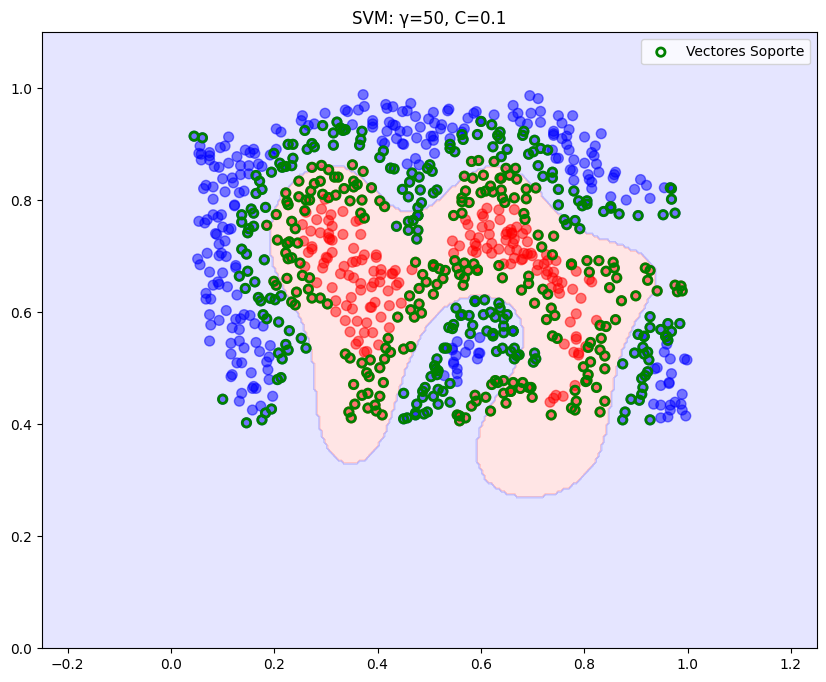

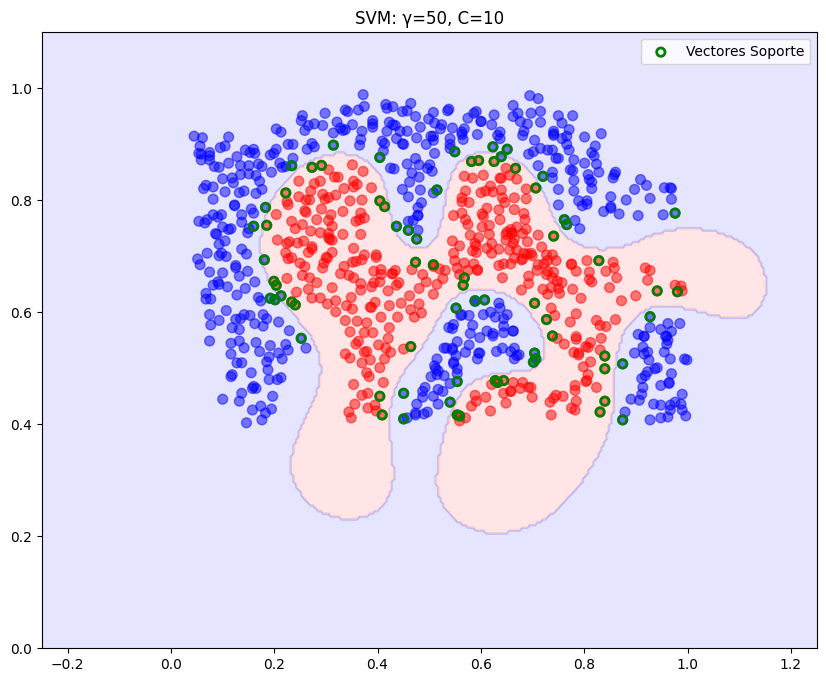

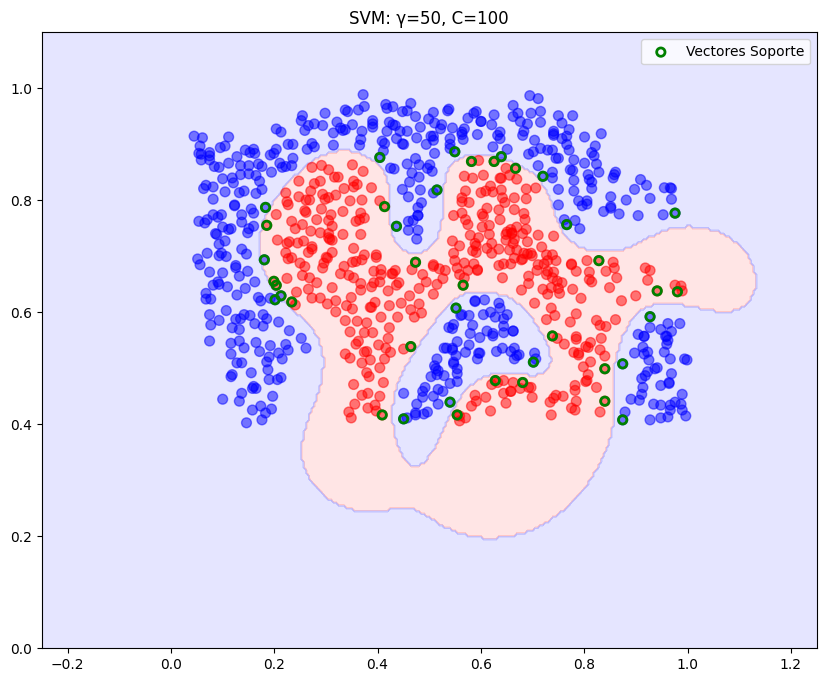

In [23]:
C_values = [ 0.1, 10, 100]

for C in C_values:
    svm_1 = SVC(kernel='rbf', gamma=50, C=C)
    svm_1.fit(X, y)
    frontera_decision(X, y, svm_1, f'SVM: γ=50, C={C}')

### Diferentes valores de γ

Se repite el mismo procedimiento para diferentes valores de γ.

* Para el caso de $\gamma$ = 1 y C = 1, este valor es mucho más bajo con el que veniamos trabajando, esto implica que el kernel RBF tiene un radio de influencia más amplio, lo que tiende a crear fronteras más suaves y menos onduladas como cuando γ era de 50, esto lo podemos ver en el gráfico, que parece trazar una separación mas general y menos ajustada a cada dato individual.

* Para el caso de γ = 10 y C = 1, se observa una frontera de decisión con un equilibrio intermedio en complejidad y ajuste. El valor mas alto de γ que el caso anteror, indica una influencia más localizada de los puntos de datos individuales, lo que permite que la frontera de decisión se adapte mejor a las formas de los clusters.

* Finalmente para el ultimo caso con γ = 100, se observa una frontera de decisión que exhibe una complejidad extrema y un ajuste muy localizado a los datos de entrenamiento. Al ser tan elevado γ, significa que el kernel RBF tiene un radio de influencia extremadamente pequeño, esto hace que la frontera de decisión sea muy sensible a cada punto de dato individual, lo que produce probablemente overfitting.



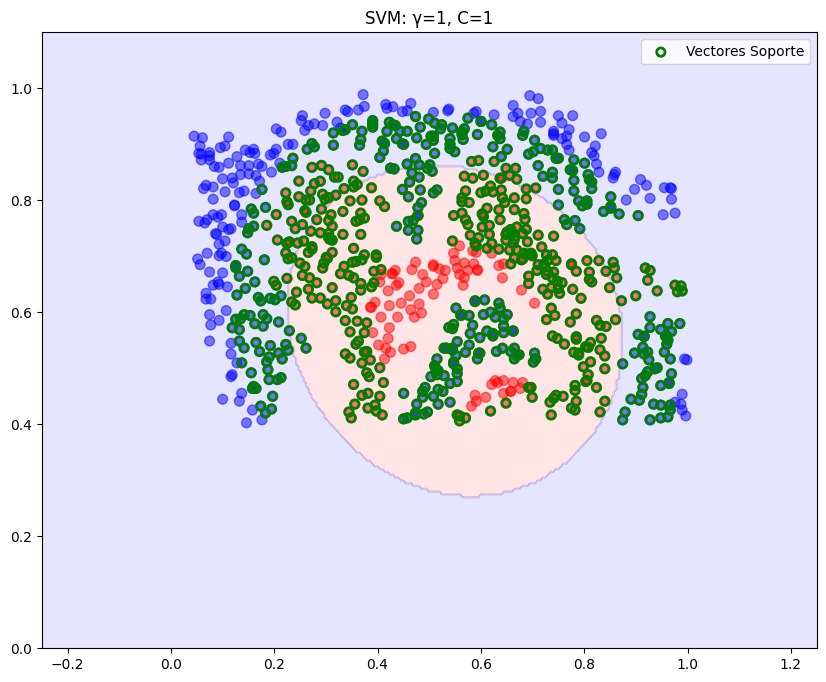

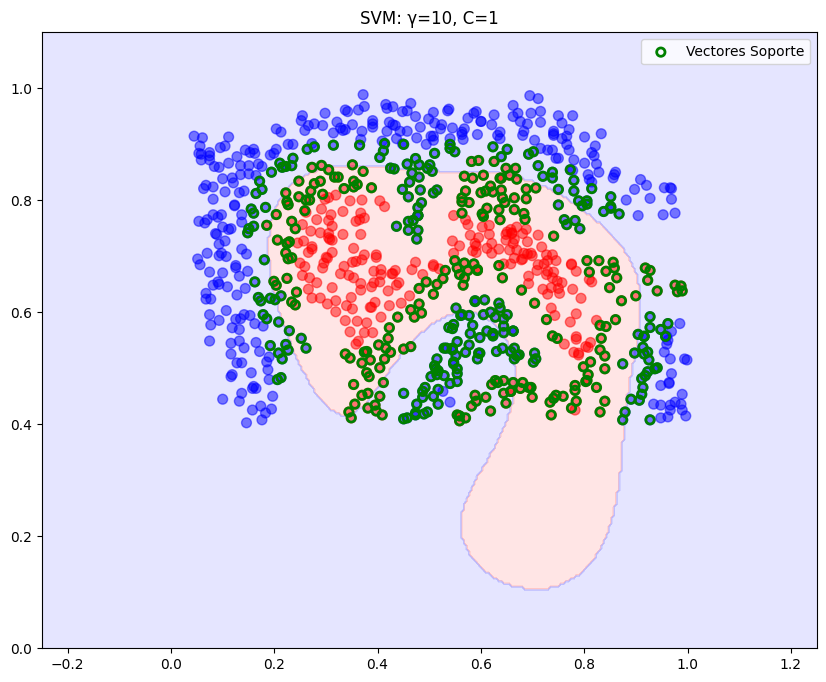

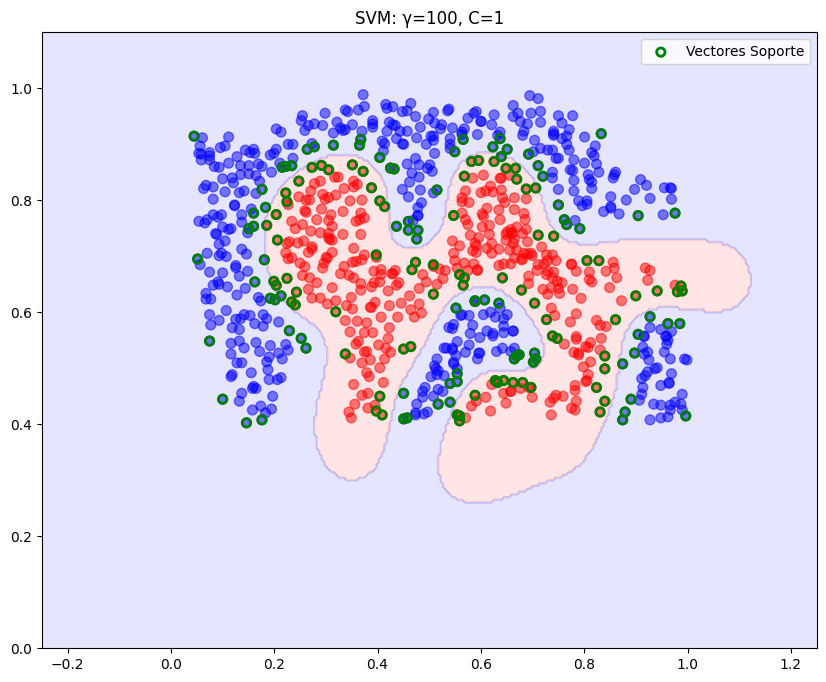

In [25]:
gamma_values = [ 1, 10, 100]
for gamma in gamma_values:
    svm = SVC(kernel='rbf', gamma=gamma, C=1)
    svm.fit(X, y)
    frontera_decision(X, y, svm, f'SVM: γ={gamma}, C=1')